In [1]:
import pandas as pd
import numpy as np
import nltk
import matplotlib.pyplot as plt

from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from nltk.stem import WordNetLemmatizer

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer

from wordcloud import WordCloud

nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

**TASK 1 - LOAD THE DATASET**

In [2]:
df = pd.read_csv('/content/IMDB Dataset.csv', engine='python')

print(df.head())

                                              review sentiment
0  One of the other reviewers has mentioned that ...  positive
1  A wonderful little production. <br /><br />The...  positive
2  I thought this was a wonderful way to spend ti...  positive
3  Basically there's a family where a little boy ...  negative
4  Petter Mattei's "Love in the Time of Money" is...  positive


**TASK 2 - CONVERT TEXT TO LOWERCASE**

In [3]:
df['lowercase_review'] = df['review'].str.lower()

# Display original review
print("ORIGINAL REVIEW:\n")
print(df['review'][0])

# Display lowercase review
print("\nLOWERCASE REVIEW:\n")
print(df['lowercase_review'][0])

ORIGINAL REVIEW:

One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me about Oz was its brutality and unflinching scenes of violence, which set in right from the word GO. Trust me, this is not a show for the faint hearted or timid. This show pulls no punches with regards to drugs, sex or violence. Its is hardcore, in the classic use of the word.<br /><br />It is called OZ as that is the nickname given to the Oswald Maximum Security State Penitentary. It focuses mainly on Emerald City, an experimental section of the prison where all the cells have glass fronts and face inwards, so privacy is not high on the agenda. Em City is home to many..Aryans, Muslims, gangstas, Latinos, Christians, Italians, Irish and more....so scuffles, death stares, dodgy dealings and shady agreements are never far away.<br /><br />I would say the main appeal of the show

**TASK 3 - TOKENIZATION**

In [4]:
df['tokens'] = df['lowercase_review'].apply(word_tokenize)

# Display tokens for first 5 samples
for i in range(5):
    print(f"\nTOKENS FOR SAMPLE {i+1}:\n")
    print(df['tokens'][i])


TOKENS FOR SAMPLE 1:

['one', 'of', 'the', 'other', 'reviewers', 'has', 'mentioned', 'that', 'after', 'watching', 'just', '1', 'oz', 'episode', 'you', "'ll", 'be', 'hooked', '.', 'they', 'are', 'right', ',', 'as', 'this', 'is', 'exactly', 'what', 'happened', 'with', 'me.', '<', 'br', '/', '>', '<', 'br', '/', '>', 'the', 'first', 'thing', 'that', 'struck', 'me', 'about', 'oz', 'was', 'its', 'brutality', 'and', 'unflinching', 'scenes', 'of', 'violence', ',', 'which', 'set', 'in', 'right', 'from', 'the', 'word', 'go', '.', 'trust', 'me', ',', 'this', 'is', 'not', 'a', 'show', 'for', 'the', 'faint', 'hearted', 'or', 'timid', '.', 'this', 'show', 'pulls', 'no', 'punches', 'with', 'regards', 'to', 'drugs', ',', 'sex', 'or', 'violence', '.', 'its', 'is', 'hardcore', ',', 'in', 'the', 'classic', 'use', 'of', 'the', 'word.', '<', 'br', '/', '>', '<', 'br', '/', '>', 'it', 'is', 'called', 'oz', 'as', 'that', 'is', 'the', 'nickname', 'given', 'to', 'the', 'oswald', 'maximum', 'security', 'state

**TASK 4 - STOPWORD REMOVAL**

In [5]:
# Load English stopwords
stop_words = set(stopwords.words('english'))

# Remove stopwords
df['no_stopwords'] = df['tokens'].apply(
    lambda x: [word for word in x if word not in stop_words]
)

# Display before and after results
print("BEFORE STOPWORD REMOVAL:\n")
print(df['tokens'][0])

print("\nAFTER STOPWORD REMOVAL:\n")
print(df['no_stopwords'][0])

BEFORE STOPWORD REMOVAL:

['one', 'of', 'the', 'other', 'reviewers', 'has', 'mentioned', 'that', 'after', 'watching', 'just', '1', 'oz', 'episode', 'you', "'ll", 'be', 'hooked', '.', 'they', 'are', 'right', ',', 'as', 'this', 'is', 'exactly', 'what', 'happened', 'with', 'me.', '<', 'br', '/', '>', '<', 'br', '/', '>', 'the', 'first', 'thing', 'that', 'struck', 'me', 'about', 'oz', 'was', 'its', 'brutality', 'and', 'unflinching', 'scenes', 'of', 'violence', ',', 'which', 'set', 'in', 'right', 'from', 'the', 'word', 'go', '.', 'trust', 'me', ',', 'this', 'is', 'not', 'a', 'show', 'for', 'the', 'faint', 'hearted', 'or', 'timid', '.', 'this', 'show', 'pulls', 'no', 'punches', 'with', 'regards', 'to', 'drugs', ',', 'sex', 'or', 'violence', '.', 'its', 'is', 'hardcore', ',', 'in', 'the', 'classic', 'use', 'of', 'the', 'word.', '<', 'br', '/', '>', '<', 'br', '/', '>', 'it', 'is', 'called', 'oz', 'as', 'that', 'is', 'the', 'nickname', 'given', 'to', 'the', 'oswald', 'maximum', 'security', 'st

**TASK 5 - STEMMING**

In [6]:
# Initialize stemmer
stemmer = PorterStemmer()

# Apply stemming
df['stemmed'] = df['no_stopwords'].apply(
    lambda x: [stemmer.stem(word) for word in x]
)

# Display first 10 stemmed outputs
for i in range(10):
    print(f"\nSTEMMED SAMPLE {i+1}:\n")
    print(df['stemmed'][i])


STEMMED SAMPLE 1:

['one', 'review', 'mention', 'watch', '1', 'oz', 'episod', "'ll", 'hook', '.', 'right', ',', 'exactli', 'happen', 'me.', '<', 'br', '/', '>', '<', 'br', '/', '>', 'first', 'thing', 'struck', 'oz', 'brutal', 'unflinch', 'scene', 'violenc', ',', 'set', 'right', 'word', 'go', '.', 'trust', ',', 'show', 'faint', 'heart', 'timid', '.', 'show', 'pull', 'punch', 'regard', 'drug', ',', 'sex', 'violenc', '.', 'hardcor', ',', 'classic', 'use', 'word.', '<', 'br', '/', '>', '<', 'br', '/', '>', 'call', 'oz', 'nicknam', 'given', 'oswald', 'maximum', 'secur', 'state', 'penitentari', '.', 'focus', 'mainli', 'emerald', 'citi', ',', 'experiment', 'section', 'prison', 'cell', 'glass', 'front', 'face', 'inward', ',', 'privaci', 'high', 'agenda', '.', 'em', 'citi', 'home', 'mani', '..', 'aryan', ',', 'muslim', ',', 'gangsta', ',', 'latino', ',', 'christian', ',', 'italian', ',', 'irish', '....', 'scuffl', ',', 'death', 'stare', ',', 'dodgi', 'deal', 'shadi', 'agreement', 'never', 'far

**TASK 6 - LEMMATIZATION**

In [7]:
# Initialize lemmatizer
lemmatizer = WordNetLemmatizer()

# Apply lemmatization
df['lemmatized'] = df['no_stopwords'].apply(
    lambda x: [lemmatizer.lemmatize(word) for word in x]
)

# Compare stemming and lemmatization
for i in range(5):
    print(f"\nSAMPLE {i+1}")

    print("\nSTEMMED:")
    print(df['stemmed'][i])

    print("\nLEMMATIZED:")
    print(df['lemmatized'][i])


SAMPLE 1

STEMMED:
['one', 'review', 'mention', 'watch', '1', 'oz', 'episod', "'ll", 'hook', '.', 'right', ',', 'exactli', 'happen', 'me.', '<', 'br', '/', '>', '<', 'br', '/', '>', 'first', 'thing', 'struck', 'oz', 'brutal', 'unflinch', 'scene', 'violenc', ',', 'set', 'right', 'word', 'go', '.', 'trust', ',', 'show', 'faint', 'heart', 'timid', '.', 'show', 'pull', 'punch', 'regard', 'drug', ',', 'sex', 'violenc', '.', 'hardcor', ',', 'classic', 'use', 'word.', '<', 'br', '/', '>', '<', 'br', '/', '>', 'call', 'oz', 'nicknam', 'given', 'oswald', 'maximum', 'secur', 'state', 'penitentari', '.', 'focus', 'mainli', 'emerald', 'citi', ',', 'experiment', 'section', 'prison', 'cell', 'glass', 'front', 'face', 'inward', ',', 'privaci', 'high', 'agenda', '.', 'em', 'citi', 'home', 'mani', '..', 'aryan', ',', 'muslim', ',', 'gangsta', ',', 'latino', ',', 'christian', ',', 'italian', ',', 'irish', '....', 'scuffl', ',', 'death', 'stare', ',', 'dodgi', 'deal', 'shadi', 'agreement', 'never', 'far

**TASK 7 - BAG OF WORDS (BoW)**

In [8]:
# Initialize CountVectorizer
cv = CountVectorizer(max_features=1000)

# Fit and transform text data
X_bow = cv.fit_transform(df['lowercase_review'])

# Display vocabulary
print("VOCABULARY:\n")
print(cv.vocabulary_)

# Display feature names
print("\nFEATURE NAMES:\n")
print(cv.get_feature_names_out())

# Display matrix shape
print("\nBOW MATRIX SHAPE:")
print(X_bow.shape)

# Display first 5 rows of BoW matrix
print("\nFIRST 5 ROWS OF BOW MATRIX:\n")
print(X_bow.toarray()[:5])

VOCABULARY:

{'one': np.int64(604), 'of': np.int64(594), 'the': np.int64(846), 'other': np.int64(614), 'has': np.int64(382), 'that': np.int64(845), 'after': np.int64(20), 'watching': np.int64(936), 'just': np.int64(452), 'episode': np.int64(257), 'you': np.int64(995), 'll': np.int64(499), 'be': np.int64(77), 'they': np.int64(855), 'are': np.int64(53), 'right': np.int64(707), 'as': np.int64(57), 'this': np.int64(861), 'is': np.int64(438), 'exactly': np.int64(270), 'what': np.int64(947), 'happened': np.int64(378), 'with': np.int64(964), 'me': np.int64(528), 'br': np.int64(109), 'first': np.int64(318), 'thing': np.int64(856), 'about': np.int64(5), 'was': np.int64(930), 'its': np.int64(442), 'and': np.int64(41), 'scenes': np.int64(727), 'violence': np.int64(923), 'which': np.int64(952), 'set': np.int64(751), 'in': np.int64(427), 'from': np.int64(335), 'word': np.int64(972), 'go': np.int64(358), 'not': np.int64(586), 'show': np.int64(763), 'for': np.int64(324), 'or': np.int64(610), 'no': np

**TASK 8 - TF-IDF VECTORIZATION**

In [9]:
# Initialize TF-IDF Vectorizer
tfidf = TfidfVectorizer(max_features=1000)

# Fit and transform text data
X_tfidf = tfidf.fit_transform(df['lowercase_review'])

# Display vocabulary
print("VOCABULARY:\n")
print(tfidf.vocabulary_)

# Display matrix shape
print("\nTF-IDF MATRIX SHAPE:")
print(X_tfidf.shape)

# Display first 5 rows
print("\nFIRST 5 ROWS OF TF-IDF MATRIX:\n")
print(X_tfidf.toarray()[:5])

VOCABULARY:

{'one': np.int64(604), 'of': np.int64(594), 'the': np.int64(846), 'other': np.int64(614), 'has': np.int64(382), 'that': np.int64(845), 'after': np.int64(20), 'watching': np.int64(936), 'just': np.int64(452), 'episode': np.int64(257), 'you': np.int64(995), 'll': np.int64(499), 'be': np.int64(77), 'they': np.int64(855), 'are': np.int64(53), 'right': np.int64(707), 'as': np.int64(57), 'this': np.int64(861), 'is': np.int64(438), 'exactly': np.int64(270), 'what': np.int64(947), 'happened': np.int64(378), 'with': np.int64(964), 'me': np.int64(528), 'br': np.int64(109), 'first': np.int64(318), 'thing': np.int64(856), 'about': np.int64(5), 'was': np.int64(930), 'its': np.int64(442), 'and': np.int64(41), 'scenes': np.int64(727), 'violence': np.int64(923), 'which': np.int64(952), 'set': np.int64(751), 'in': np.int64(427), 'from': np.int64(335), 'word': np.int64(972), 'go': np.int64(358), 'not': np.int64(586), 'show': np.int64(763), 'for': np.int64(324), 'or': np.int64(610), 'no': np

**TASK 9 - WORD CLOUD**

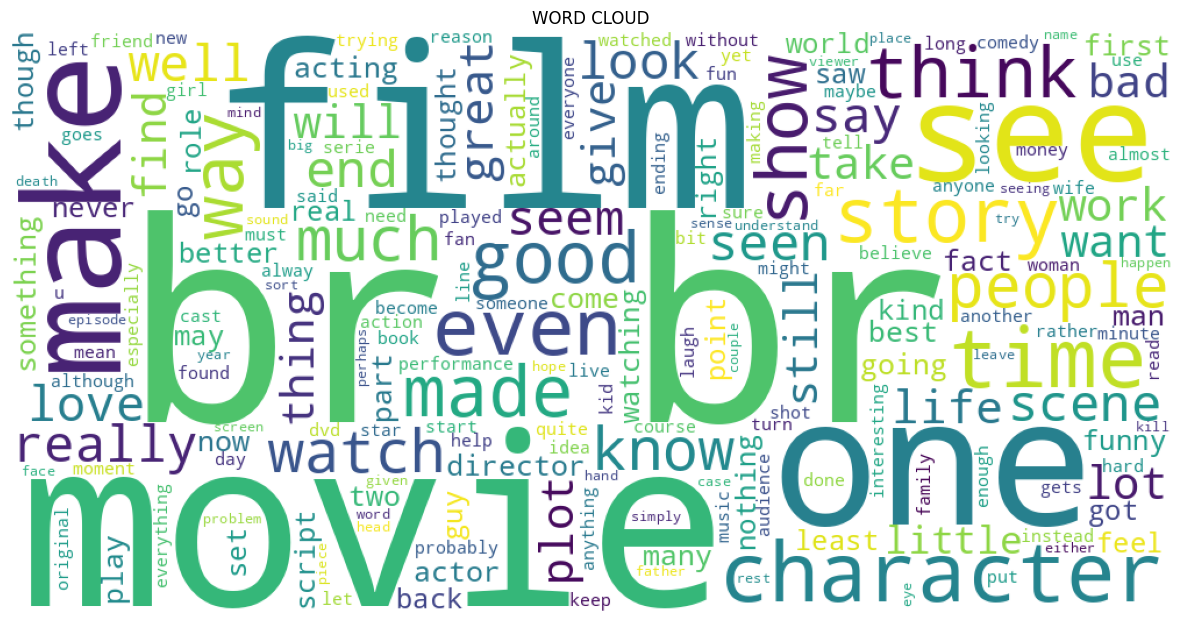

In [10]:
# Join all reviews into one text
text = " ".join(df['lowercase_review'])

# Generate word cloud
wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color='white'
).generate(text)

# Display word cloud
plt.figure(figsize=(15,8))
plt.imshow(wordcloud)
plt.axis('off')
plt.title("WORD CLOUD")
plt.show()